In [399]:
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense
from keras.datasets import fashion_mnist
import matplotlib.pyplot as plt
import numpy as np
from keras import losses,optimizers,  metrics

In [400]:
(x_train,y_train),(x_test,y_test) = fashion_mnist.load_data()

In [401]:
x_train,x_test = x_train.reshape(-1,28*28),x_test.reshape(-1,28*28)

In [402]:
x_train = x_train.astype('float32')/255
x_test = x_test.astype('float32')/255

In [403]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

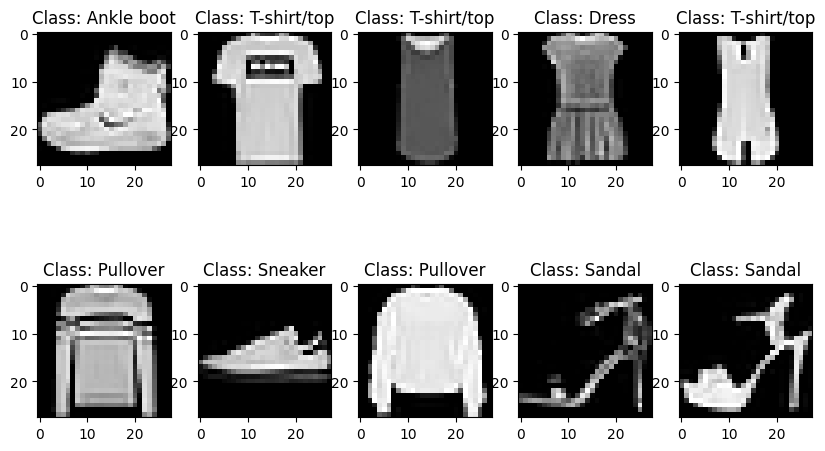

In [404]:
plt.figure(figsize=(10, 6))
for i in range(10):
  plt.subplot(2,5,i+1)
  plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
  plt.title(f'Class: {class_names[y_train[i]]}')

plt.show()

In [405]:
model = Sequential([
    Dense(512,activation='relu',input_shape=(784,)),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(10,activation='softmax')
])

In [406]:
model.compile(
    optimizer=optimizers.RMSprop(learning_rate=0.0005),
    loss= losses.sparse_categorical_crossentropy,
    metrics=['accuracy']
)

In [407]:
model.summary()

Model: "sequential_34"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_153 (Dense)               │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_154 (Dense)               │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_155 (Dense)               │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_156 (Dense)               │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 567,434 (2.16 MB)

 Trainable params: 567,434 (2.16 MB)

 Non-trainable params: 0 (0.00 B)

In [408]:
history = model.fit(x_train,y_train,epochs=40,batch_size=128,validation_data=(x_test,y_test))

Epoch 1/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7348 - loss: 0.7415 - val_accuracy: 0.8263 - val_loss: 0.4570
Epoch 2/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8541 - loss: 0.3988 - val_accuracy: 0.8493 - val_loss: 0.4078
Epoch 3/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8729 - loss: 0.3410 - val_accuracy: 0.8586 - val_loss: 0.3889
Epoch 4/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8845 - loss: 0.3111 - val_accuracy: 0.8755 - val_loss: 0.3630
Epoch 5/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8911 - loss: 0.2886 - val_accuracy: 0.8643 - val_loss: 0.3745
Epoch 6/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8990 - loss: 0.2688 - val_accuracy: 0.8762 - val_loss: 0.3410
Epoch 7/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9059 - loss: 0.2496 - val_accuracy: 0.8700 - val_loss: 0.3629
Epoch 8/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9091 - loss: 0.2423 - val_accuracy: 0.

/tmp/ipython-input-3187115810.py:6: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  plt.plot(epochs,test_loss_values,'b',label='Test Loss',color='red')
/tmp/ipython-input-3187115810.py:20: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  plt.plot(epochs,test_loss_values,'b',label='Test Accuracy',color='red')


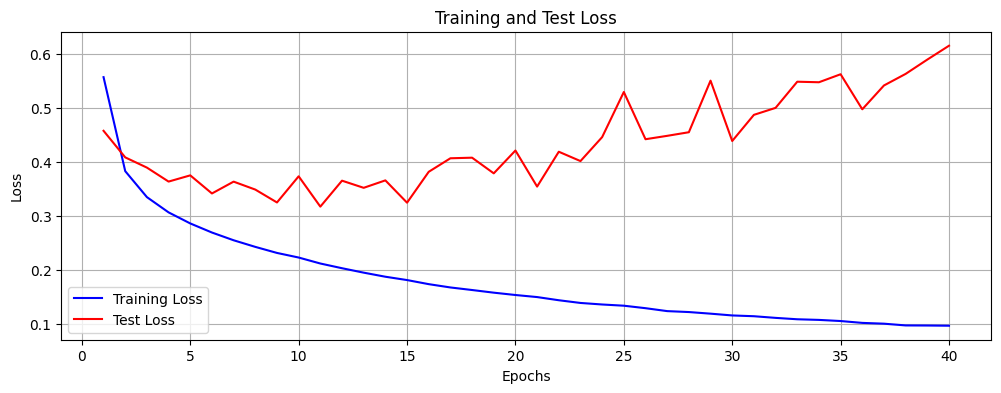

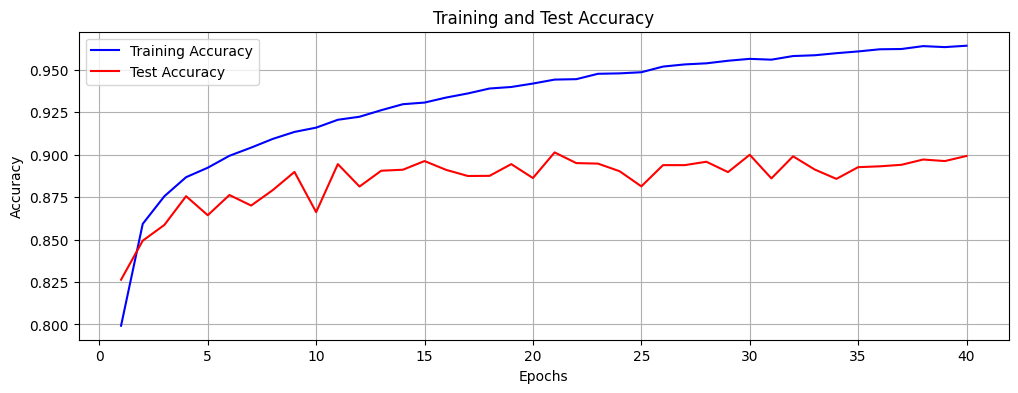

In [409]:
plt.figure(figsize=(12, 4))
loss_values=history.history['loss']
test_loss_values=history.history['val_loss']
epochs=range(1,len(history.history['loss'])+1)
plt.plot(epochs,loss_values,'b',label='Training Loss')
plt.plot(epochs,test_loss_values,'b',label='Test Loss',color='red')
plt.title('Training and Test Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid()
plt.legend()



plt.figure(figsize=(12, 4))
loss_values=history.history['accuracy']
test_loss_values=history.history['val_accuracy']
epochs=range(1,len(history.history['accuracy'])+1)
plt.plot(epochs,loss_values,'b',label='Training Accuracy')
plt.plot(epochs,test_loss_values,'b',label='Test Accuracy',color='red')
plt.title('Training and Test Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.show()

In [410]:
results = model.evaluate(x_test, y_test)
print(results)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8959 - loss: 0.6383
[0.6145164370536804, 0.8992000222206116]


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


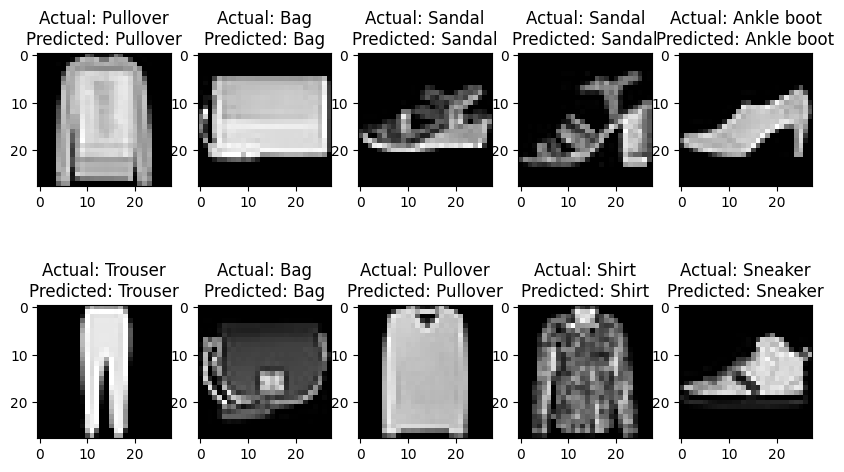

In [414]:
y_predict = model.predict(x_test)

random_index = np.random.choice(x_test.shape[0],10,replace=False)

plt.figure(figsize=(10, 6))

for i,index in enumerate(random_index):
  plt.subplot(2,5,i+1)
  plt.imshow(x_test[index].reshape(28, 28), cmap='gray')
  plt.title(f'Actual: {class_names[y_test[index]]}\nPredicted: {class_names[np.argmax(y_predict[index])]}')

plt.show()

Отже достигнути точності більше 91% в мене не вийшло, максимумз підбором в мене вийшло отримати 89,5% навіть не 90%, але на предіктах отримав дуже гарні результати